Image downloaded successfully!


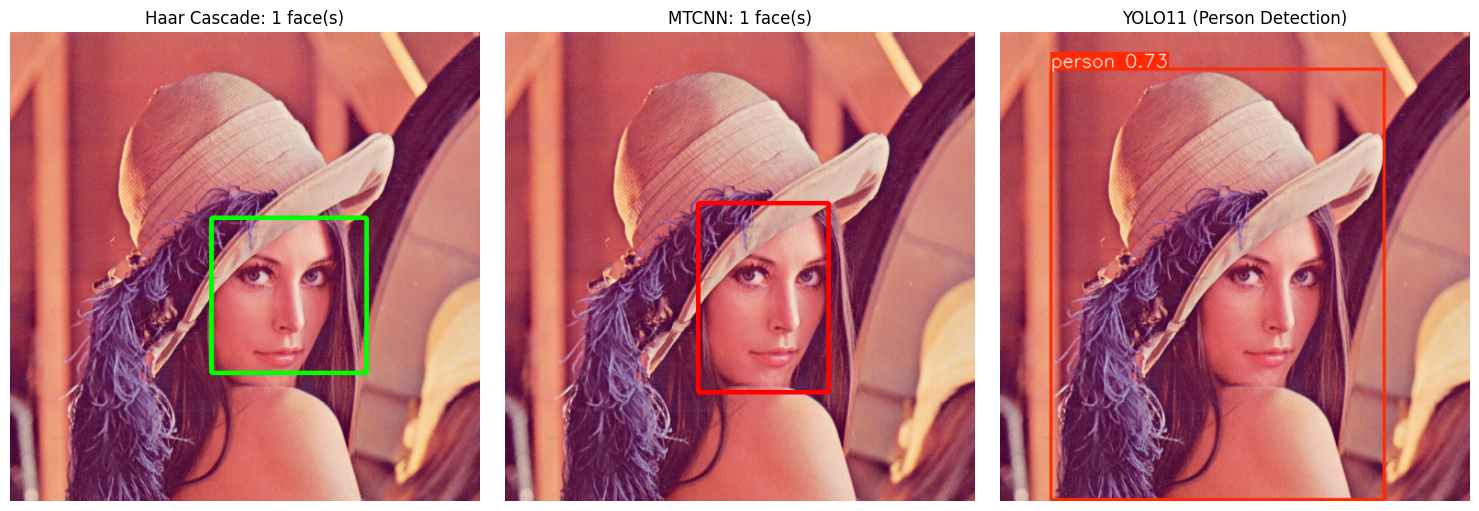

In [16]:
# 1. Install required packages (Run this once)
!pip install mtcnn ultralytics -q

import urllib.request
import cv2
import os
import matplotlib.pyplot as plt
from mtcnn import MTCNN
from ultralytics import YOLO

# 2. Download the test image
image_url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"
image_path = "test_face.jpg"
urllib.request.urlretrieve(image_url, image_path)
print("Image downloaded successfully!")

# Load the image for all models
frame = cv2.imread(image_path)
rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) # For plotting
gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY) # For Haar

# MODEL 1: Haar Cascade

casc_path = os.path.dirname(cv2.__file__) + "/data/haarcascade_frontalface_default.xml"
face_cascade = cv2.CascadeClassifier(casc_path)
haar_faces = face_cascade.detectMultiScale(gray_frame, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

haar_img = rgb_frame.copy()
for (x, y, w, h) in haar_faces:
    cv2.rectangle(haar_img, (x, y), (x + w, y + h), (0, 255, 0), 3)

# MODEL 2: MTCNN

detector = MTCNN()
mtcnn_faces = detector.detect_faces(rgb_frame)

mtcnn_img = rgb_frame.copy()
for face in mtcnn_faces:
    x, y, w, h = face['box']
    if face['confidence'] > 0.90:
        cv2.rectangle(mtcnn_img, (x, y), (x + w, y + h), (255, 0, 0), 3)

# MODEL 3: YOLO11

model = YOLO('yolo11n.pt') 
results = model.predict(source=rgb_frame, classes=[0], conf=0.25, verbose=False)
yolo_img = results[0].plot()

# Display All Results Together

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(haar_img)
axes[0].set_title(f"Haar Cascade: {len(haar_faces)} face(s)")
axes[0].axis('off')

axes[1].imshow(mtcnn_img)
axes[1].set_title(f"MTCNN: {len(mtcnn_faces)} face(s)")
axes[1].axis('off')

axes[2].imshow(yolo_img)
axes[2].set_title("YOLO11 (Person Detection)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

Accuracy Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



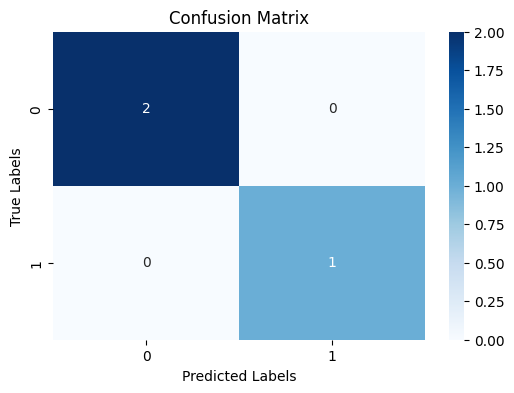

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create a dummy dataset (Replace this with your actual CSV file later)
data = {
    'Age': [22, 25, 47, 52, 46, 56, 27, 28, 30, 60],
    'Income': [15, 20, 60, 70, 65, 80, 22, 25, 30, 90],
    'Bought_Item': [0, 0, 1, 1, 1, 1, 0, 0, 0, 1]  # 0 = No, 1 = Yes
}
df = pd.DataFrame(data)

# 2. Define Features (X) and Target (y)
X = df[['Age', 'Income']]
y = df['Bought_Item']

# 3. Split the data into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 4. Train a Machine Learning Model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# 5. Generate Predictions on the test data
y_pred = model.predict(X_test)

# EVALUATION METRICS (What you originally asked for)


# A. Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}\n")

# B. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# C. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()